# Deep Learning Model

## Data Cleaning

In [1]:
import psycopg2
from sqlalchemy import create_engine, Column, Integer, String
from sqlalchemy.ext.declarative import declarative_base
from sqlalchemy.orm import sessionmaker
import pandas as pd
import numpy as np
from parameters import db_params
from sklearn.preprocessing import LabelEncoder
import matplotlib.pyplot as plt


# Create a connection string
conn_string = f"postgresql+psycopg2://{db_params['user']}:{db_params['password']}@{db_params['host']}:{db_params['port']}/{db_params['database']}"

# Create an SQLAlchemy engine
engine = create_engine(conn_string)

# Use pandas to execute a query and load data into a DataFrame
query = "SELECT * FROM data_lake.safe_driving"
df_safe_driving = pd.read_sql(query, engine)

# Close the connection
engine.dispose()

# Ensure 'event_start' and 'event_end' are in datetime format
df_safe_driving['event_start'] = pd.to_datetime(df_safe_driving['event_start'])
df_safe_driving['event_end'] = pd.to_datetime(df_safe_driving['event_end'])

# Check for duplicate values
dup_count = df_safe_driving.duplicated().sum()
print('There are', dup_count, 'duplicate values')

# Re-check for missing values in different forms
missing_count = df_safe_driving.isnull().sum().sum()
print('There are', missing_count, 'missing values')

# Set the future option to opt-in to the new behavior
pd.set_option('future.no_silent_downcasting', True)

# Replace empty strings with NaN in the 'road_number' column
df_safe_driving['road_number'] = df_safe_driving['road_number'].replace("", np.nan)

# Verify that the replacement has been done
missing_values_count = df_safe_driving.isnull().sum()
print("Total missing values per column:")
print(missing_values_count[missing_values_count > 0])

# Summarize findings
total_missing = missing_values_count.sum()
print(f"Total number of missing values (including special values): {total_missing}")

# Verify that the rows with missing values
print(df_safe_driving.isna().sum())

# Print start cleaning
print('\nStarting Cleaning:\n')

# Remove the 'road_number' column
df_safe_driving = df_safe_driving.drop('road_number', axis=1)

# Verify that the rows with missing 'road_number' values have been removed
print(df_safe_driving.isna().sum())

# Strip whitespace from the 'category' column
df_safe_driving['category'] = df_safe_driving['category'].str.strip()

# Print the unique values
print(df_safe_driving['category'].unique())

# Check for duplicate values
dup_count = df_safe_driving.duplicated().sum()
print('After cleaning there are', dup_count, 'duplicate values')

# Re-check for missing values in different forms
missing_count = df_safe_driving.isnull().sum().sum()
print('After cleaning there are', missing_count, 'missing values')

df_safe_driving.head()


There are 0 duplicate values
There are 0 missing values
Total missing values per column:
road_number    964488
dtype: int64
Total number of missing values (including special values): 964488
eventid                   0
event_start               0
event_end                 0
duration_seconds          0
latitude                  0
longitude                 0
speed_kmh                 0
end_speed_kmh             0
maxwaarde                 0
category                  0
incident_severity         0
is_valid                  0
road_segment_id           0
road_manager_type         0
road_number          964488
road_name                 0
place_name                0
municipality_name         0
road_manager_name         0
dtype: int64

Starting Cleaning:

eventid              0
event_start          0
event_end            0
duration_seconds     0
latitude             0
longitude            0
speed_kmh            0
end_speed_kmh        0
maxwaarde            0
category             0
incident_sever

,eventid,event_start,event_end,duration_seconds,latitude,longitude,speed_kmh,end_speed_kmh,maxwaarde,category,incident_severity,is_valid,road_segment_id,road_manager_type,road_name,place_name,municipality_name,road_manager_name
0,33759830,2019-08-20 18:18:37.400,2019-08-20 18:18:38.500,1.1,51.62137,4.735568,22.530815,30.577536,0.703283,HARSH CORNERING,HC1,True,219207049,G,Overkroetenlaan,Breda,Breda,Breda
1,33311983,2019-08-20 18:21:46.400,2019-08-20 18:21:47.600,1.2,51.59374,4.821908,33.796223,45.061630,0.854562,HARSH CORNERING,HC1,True,600123819,G,Nieuwe Kadijk,Breda,Breda,Breda
2,33569633,2019-08-20 05:27:17.600,2019-08-20 05:27:20.500,2.9,51.58176,4.826588,38.624256,33.796223,0.854562,HARSH CORNERING,HC1,True,231198030,G,Franklin Rooseveltlaan,Breda,Breda,Breda
3,32878743,2019-08-20 21:42:59.800,2019-08-20 21:43:02.900,3.1,51.59364,4.822749,54.717697,54.717697,0.804672,HARSH CORNERING,HC1,True,600123821,G,Tilburgseweg,Breda,Breda,Breda
4,32989777,2019-08-20 10:31:21.500,2019-08-20 10:31:22.900,1.4,51.59355,4.803754,27.358849,22.530815,0.733861,HARSH CORNERING,HC1,True,600754354,G,Teteringsedijk,Breda,Breda,Breda


## Cleaning outliers

In [2]:
# Count the number of rows before removing outliers
rows_before = df_safe_driving.shape[0]

# Define the coordinates of the outliers
outlier_coords = [(51.605330, 4.779188), (51.590760, 4.811617)]

# Remove rows for outliers
for coord in outlier_coords:
    df_safe_driving = df_safe_driving[~((df_safe_driving['latitude'] == coord[0]) & (df_safe_driving['longitude'] == coord[1]))]

# Find the index of the outlier
outlier_index = df_safe_driving[df_safe_driving['duration_seconds'] > 500].index

# Drop the outlier row from the DataFrame
df_safe_driving = df_safe_driving.drop(outlier_index)

# Count the number of rows after removing outliers
rows_after = df_safe_driving.shape[0]

# Calculate the number of rows removed
rows_removed = rows_before - rows_after

# Print the number of rows removed
print("Number of rows removed:", rows_removed)

Number of rows removed: 11


## Creating bins

In [3]:
# Initialize LabelEncoder
label_encoder = LabelEncoder()

# Encode the 'category' column
df_safe_driving['category_encoded'] = label_encoder.fit_transform(df_safe_driving['category'])

# Strip whitespace from the 'category' column
df_safe_driving['incident_severity'] = df_safe_driving['incident_severity'].str.strip()

# Print the unique values
print(df_safe_driving['incident_severity'].unique())

def classify_incident_severity_corrected(severity):
    low = ['HA1', 'HB1', 'HC1', 'SP1', 'HC4', 'HC13']
    medium = ['HA2', 'HB2', 'HC2', 'HC5', 'HC7', 'HC14', 'HC16', 'SP2', 'SP3', 'HC6', 'HC8', 'HC10', 'HC15', 'HC17', 'HC19']
    high = ['HA3', 'HB3', 'HC3', 'HC9', 'HC11', 'HC12', 'HC18', 'HC20', 'HC21', 'SP4', 'SP5']
    
    if severity in low:
        return 'Low'
    elif severity in medium:
        return 'Medium'
    elif severity in high:
        return 'High'
    else:
        return 'Unknown'

# Apply the corrected classification function
df_safe_driving['incident_severity_bin'] = df_safe_driving['incident_severity'].apply(classify_incident_severity_corrected)

# Display the updated DataFrame
df_safe_driving.head()

['HC1' 'SP1' 'HB1' 'SP3' 'SP2' 'HB2' 'HC2' 'HA1' 'HC13' 'HA2' 'HC4' 'SP5'
 'SP4' 'HC7' 'HB3' 'HA3' 'HC3' 'HC6' 'HC14' 'HC8' 'HC5' 'HC16' 'HC17'
 'HC15' 'HC10' 'HC19' 'HC11' 'HC20' 'HC18' 'HC21']


,eventid,event_start,event_end,duration_seconds,latitude,longitude,speed_kmh,end_speed_kmh,maxwaarde,category,incident_severity,is_valid,road_segment_id,road_manager_type,road_name,place_name,municipality_name,road_manager_name,category_encoded,incident_severity_bin
0,33759830,2019-08-20 18:18:37.400,2019-08-20 18:18:38.500,1.1,51.62137,4.735568,22.530815,30.577536,0.703283,HARSH CORNERING,HC1,True,219207049,G,Overkroetenlaan,Breda,Breda,Breda,2,Low
1,33311983,2019-08-20 18:21:46.400,2019-08-20 18:21:47.600,1.2,51.59374,4.821908,33.796223,45.061630,0.854562,HARSH CORNERING,HC1,True,600123819,G,Nieuwe Kadijk,Breda,Breda,Breda,2,Low
2,33569633,2019-08-20 05:27:17.600,2019-08-20 05:27:20.500,2.9,51.58176,4.826588,38.624256,33.796223,0.854562,HARSH CORNERING,HC1,True,231198030,G,Franklin Rooseveltlaan,Breda,Breda,Breda,2,Low
3,32878743,2019-08-20 21:42:59.800,2019-08-20 21:43:02.900,3.1,51.59364,4.822749,54.717697,54.717697,0.804672,HARSH CORNERING,HC1,True,600123821,G,Tilburgseweg,Breda,Breda,Breda,2,Low
4,32989777,2019-08-20 10:31:21.500,2019-08-20 10:31:22.900,1.4,51.59355,4.803754,27.358849,22.530815,0.733861,HARSH CORNERING,HC1,True,600754354,G,Teteringsedijk,Breda,Breda,Breda,2,Low


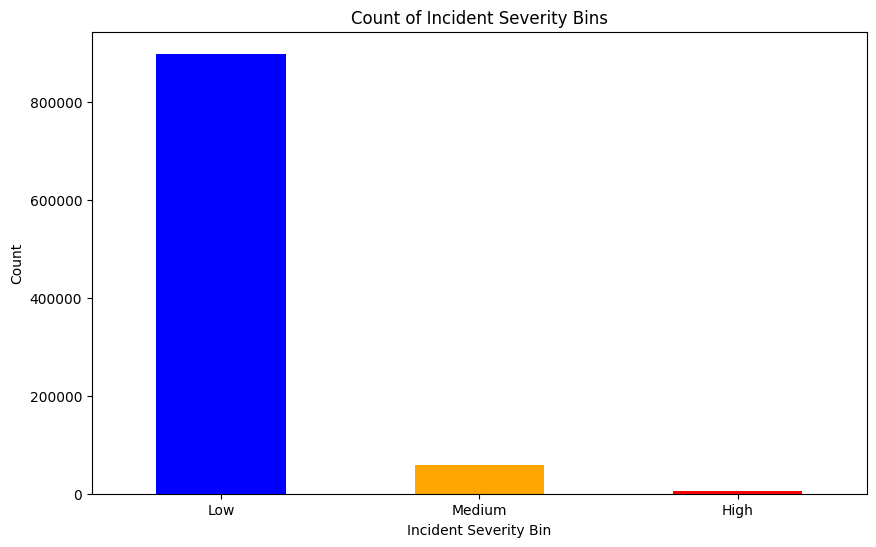

In [4]:
# Create a count histogram for the incident_severity_bin
plt.figure(figsize=(10, 6))
df_safe_driving['incident_severity_bin'].value_counts().plot(kind='bar', color=['blue', 'orange', 'red'])
plt.title('Count of Incident Severity Bins')
plt.xlabel('Incident Severity Bin')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.show()

## Resampling the bins

Random Sampling with Replacement bin counts:
 incident_severity_bin
High      63533
Low       63533
Medium    63533
Name: count, dtype: int64


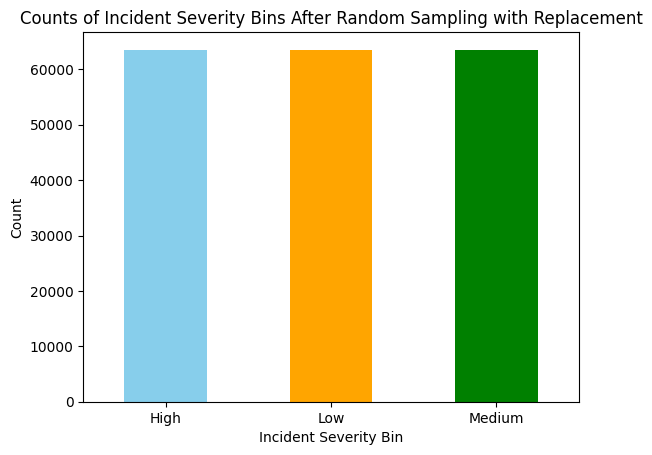

In [5]:
# Apply Random Sampling with Replacement
sampled_dfs = []
for bin_label, group in df_safe_driving.groupby('incident_severity_bin'):
    sampled_dfs.append(group.sample(n=63533, replace=True, random_state=42))
df_sampled_replacement = pd.concat(sampled_dfs)

# Display the count for each incident severity bin in the resampled data
sampled_replacement_bin_counts = df_sampled_replacement['incident_severity_bin'].value_counts()
print("Random Sampling with Replacement bin counts:\n", sampled_replacement_bin_counts)

# Set the resampled DataFrame to df_safe_driving
df_safe_driving = df_sampled_replacement

# Plot histogram
sampled_replacement_bin_counts.plot(kind='bar', color=['skyblue', 'orange', 'green'])
plt.xlabel('Incident Severity Bin')
plt.ylabel('Count')
plt.title('Counts of Incident Severity Bins After Random Sampling with Replacement')
plt.xticks(rotation=0)
plt.show()

## Train test split

In [6]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import logging
import os

# Set the information type to 2, this will only show error messages
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '2'

# Suppress TensorFlow warnings
logging.getLogger('tensorflow').setLevel(logging.ERROR)

# Import TensorFlow
import tensorflow as tf
from tensorflow.keras.utils import to_categorical

# Features and target
X = df_safe_driving[['duration_seconds', 'speed_kmh', 'end_speed_kmh', 'maxwaarde', 'category_encoded']]  # Features
y = df_safe_driving['incident_severity_bin']

# Encode the string labels to integers
label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)

# One-hot encode the target variable
y_one_hot = to_categorical(y_encoded)

# Step 2: Split the data into train and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y_one_hot, test_size=0.2, random_state=42)

# Step 3: Split the train data into train and validation sets
X_train, X_val, y_train, y_val = train_test_split(X_train, y_train, test_size=0.2, random_state=42)

# Step 4: Standardize the features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

2024-06-05 10:14:51.465648: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:9261] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2024-06-05 10:14:51.465714: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:607] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2024-06-05 10:14:51.467001: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1515] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


## Building the deep learning model

In [7]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization

# Create the model
model_1 = Sequential()

# Add layers to the model
model_1.add(Dense(128, input_dim=X_train_scaled.shape[1], activation='relu'))
model_1.add(Dropout(0.5))
model_1.add(Dense(64, activation='relu'))
model_1.add(Dropout(0.5))
model_1.add(Dense(32, activation='relu'))
model_1.add(Dropout(0.5))
model_1.add(Dense(y_train.shape[1], activation='softmax'))

# Compile the model
model_1.compile(loss='categorical_crossentropy', optimizer='adam', metrics=['accuracy'])

# Display model summary
model_1.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense (Dense)               (None, 128)               768       
                                                                 
 dropout (Dropout)           (None, 128)               0         
                                                                 
 dense_1 (Dense)             (None, 64)                8256      
                                                                 
 dropout_1 (Dropout)         (None, 64)                0         
                                                                 
 dense_2 (Dense)             (None, 32)                2080      
                                                                 
 dropout_2 (Dropout)         (None, 32)                0         
                                                                 
 dense_3 (Dense)             (None, 3)                 9

## Training and plotting train history

Epoch 1/25


I0000 00:00:1717582497.359365  153064 device_compiler.h:186] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


1906/1906 [==============================] - 11s 4ms/step - loss: 0.8303 - accuracy: 0.6432 - val_loss: 0.7161 - val_accuracy: 0.7030
Epoch 2/25
1906/1906 [==============================] - 8s 4ms/step - loss: 0.7551 - accuracy: 0.6916 - val_loss: 0.6923 - val_accuracy: 0.7038
Epoch 3/25
1906/1906 [==============================] - 8s 4ms/step - loss: 0.7256 - accuracy: 0.7040 - val_loss: 0.6545 - val_accuracy: 0.7303
Epoch 4/25
1906/1906 [==============================] - 8s 4ms/step - loss: 0.7069 - accuracy: 0.7156 - val_loss: 0.6459 - val_accuracy: 0.7307
Epoch 5/25
1906/1906 [==============================] - 8s 4ms/step - loss: 0.6941 - accuracy: 0.7205 - val_loss: 0.6472 - val_accuracy: 0.7293
Epoch 6/25
1906/1906 [==============================] - 8s 4ms/step - loss: 0.6886 - accuracy: 0.7219 - val_loss: 0.6419 - val_accuracy: 0.7306
Epoch 7/25
1906/1906 [==============================] - 8s 4ms/step - loss: 0.6840 - accuracy: 0.7235 - val_loss: 0.6444 - val_accuracy: 0.7301
Ep

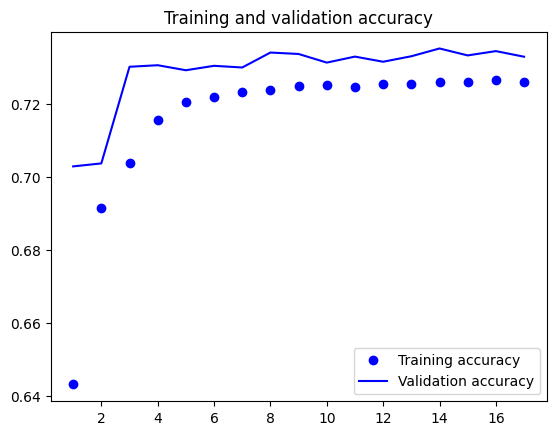

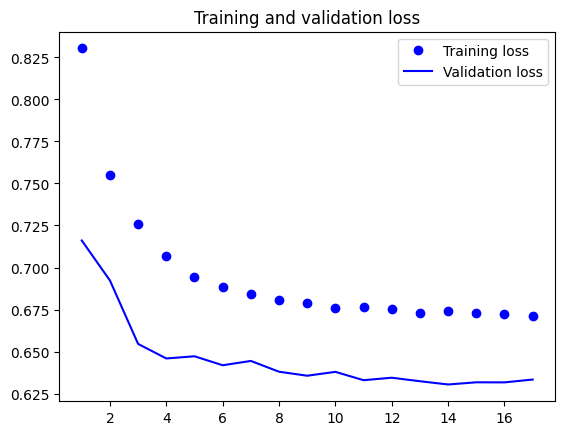

In [8]:
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

def train_model(model, X_train, y_train, X_val, y_val, callbacks=None, batch_size=64, epochs=10):
    """
    Train the specified Keras model.

    Parameters:
        model (keras.models.Sequential): The Keras model to train.
        X_train (numpy.ndarray): The training features.
        y_train (numpy.ndarray): The training labels.
        X_val (numpy.ndarray): The validation features.
        y_val (numpy.ndarray): The validation labels.
        callbacks (list): Optional list of Keras callbacks. Default is None.
        batch_size (int): Batch size for training. Default is 64.
        epochs (int): Number of epochs for training. Default is 10.

    Returns:
        history: The training history.
    """
    history = model.fit(
        x=X_train,
        y=y_train,
        epochs=epochs,
        validation_data=(X_val, y_val),
        callbacks=callbacks,
        batch_size=batch_size
    )
    return history

def plot_training_history(history):
    """
    Plot the training and validation accuracy and loss.

    Parameters:
        history: The training history object returned by Keras.
    """
    accuracy = history.history["accuracy"]
    val_accuracy = history.history["val_accuracy"]
    loss = history.history["loss"]
    val_loss = history.history["val_loss"]
    epochs = range(1, len(accuracy) + 1)

    # Plot training and validation accuracy
    plt.plot(epochs, accuracy, "bo", label="Training accuracy")
    plt.plot(epochs, val_accuracy, "b", label="Validation accuracy")
    plt.title("Training and validation accuracy")
    plt.legend()
    plt.figure()

    # Plot training and validation loss
    plt.plot(epochs, loss, "bo", label="Training loss")
    plt.plot(epochs, val_loss, "b", label="Validation loss")
    plt.title("Training and validation loss")
    plt.legend()
    plt.show()

callbacks_model_1 = [
    EarlyStopping(
        monitor="val_loss",
        patience=3,  # Number of epochs with no improvement after which training will be stopped
        restore_best_weights=True  # Restores the model weights from the epoch with the best value of the monitored quantity
    )
]

# Train the model
history_1 = train_model(
    model_1,
    X_train_scaled,
    y_train,
    X_val_scaled,
    y_val,
    callbacks=callbacks_model_1,
    batch_size=64,
    epochs=25
)

# Plot training history
plot_training_history(history_1)

## Evaluating the model

1192/1192 [==============================] - 1s 912us/step
Classification Report:
              precision    recall  f1-score   support

        High       0.64      0.87      0.74     12607
         Low       0.77      0.84      0.81     12685
      Medium       0.87      0.48      0.62     12828

    accuracy                           0.73     38120
   macro avg       0.76      0.73      0.72     38120
weighted avg       0.76      0.73      0.72     38120



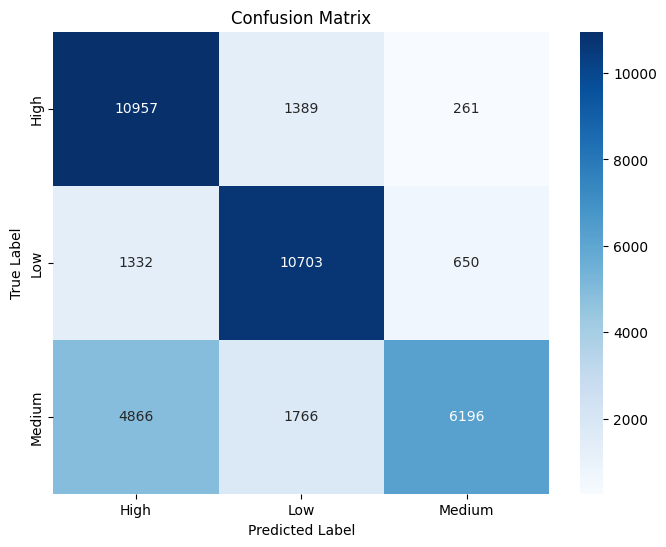

In [9]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

# Set the class names to their correct labels
class_names = df_safe_driving['incident_severity_bin'].unique()

def generate_classification_report(model, X_test, y_test, class_names):
    """
    Generate classification report and confusion matrix.

    Parameters:
        model (keras.models.Sequential): The trained Keras model.
        X_test (numpy.ndarray): The test features.
        y_test (numpy.ndarray): The true labels for the test data.
        class_names (list): List of class names.

    Returns:
        report (str): Classification report.
        cm (numpy.ndarray): Confusion matrix.
    """
    # Generate predictions
    y_pred = model.predict(X_test)
    y_pred_classes = y_pred.argmax(axis=1)
    y_test_classes = y_test.argmax(axis=1)

    # Generate classification report
    report = classification_report(y_test_classes, y_pred_classes, target_names=class_names)

    # Create confusion matrix
    cm = confusion_matrix(y_test_classes, y_pred_classes)

    return report, cm

def plot_confusion_matrix(cm, class_names):
    """
    Plot the confusion matrix using Seaborn.

    Parameters:
        cm (numpy.ndarray): Confusion matrix.
        class_names (list): List of class names.
    """
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
    plt.xlabel('Predicted Label')
    plt.ylabel('True Label')
    plt.title('Confusion Matrix')
    plt.show()

# Generate classification report and confusion matrix
report, cm = generate_classification_report(model_1, X_test_scaled, y_test, class_names)

# Print classification report
print("Classification Report:")
print(report)

# Plot confusion matrix
plot_confusion_matrix(cm, class_names)

## Error analysis

In [10]:
def perform_error_analysis(model, X_test, y_test, class_names):
    """
    Perform error analysis on the model's predictions.

    Parameters:
        model (keras.models.Sequential): The trained Keras model.
        X_test (numpy.ndarray): The test features.
        y_test (numpy.ndarray): The true labels for the test data.
        class_names (list): List of class names.
    """
    # Generate predictions
    y_pred = model.predict(X_test)
    y_pred_classes = y_pred.argmax(axis=1)
    y_test_classes = y_test.argmax(axis=1)

    # Find instances where predictions are incorrect
    incorrect_indices = [i for i, (pred, true) in enumerate(zip(y_pred_classes, y_test_classes)) if pred != true]

    # Display some examples of incorrect predictions
    for idx in incorrect_indices[:5]:
        print(f"True label: {class_names[y_test_classes[idx]]}, Predicted label: {class_names[y_pred_classes[idx]]}")
        # You can also display the corresponding input features here if needed

# Perform error analysis
perform_error_analysis(model_1, X_test_scaled, y_test, class_names)


1192/1192 [==============================] - 1s 928us/step
True label: High, Predicted label: Low
True label: Medium, Predicted label: High
True label: Medium, Predicted label: High
True label: Medium, Predicted label: High
True label: Medium, Predicted label: High


## Feature importance

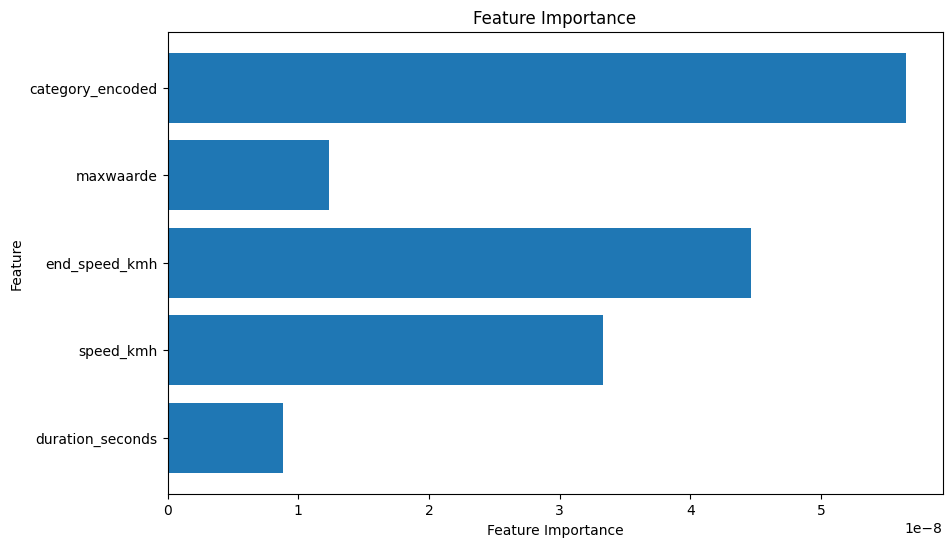

In [11]:
import tensorflow as tf

def calculate_feature_importance(model, X):
    """
    Calculate feature importance using gradients.

    Parameters:
        model (keras.models.Sequential): The trained Keras model.
        X (numpy.ndarray): The input features.

    Returns:
        feature_importance (numpy.ndarray): Feature importance scores.
    """
    # Convert input features to TensorFlow tensor
    X_tensor = tf.convert_to_tensor(X, dtype=tf.float32)

    # Calculate gradients
    with tf.GradientTape() as tape:
        tape.watch(X_tensor)
        predictions = model(X_tensor)
    gradients = tape.gradient(predictions, X_tensor)

    # Calculate feature importance as the mean absolute gradient
    feature_importance = np.mean(np.abs(gradients), axis=0)

    return feature_importance

feature_names = X.columns

# Calculate feature importance
feature_importance = calculate_feature_importance(model_1, X_test_scaled)

# Plot feature importance
plt.figure(figsize=(10, 6))
plt.barh(range(len(feature_importance)), feature_importance, align='center')
plt.yticks(range(len(feature_importance)), feature_names)  # Assuming you have feature names
plt.xlabel('Feature Importance')
plt.ylabel('Feature')
plt.title('Feature Importance')
plt.show()